<a href="https://colab.research.google.com/github/bhandarisiddharth142-sys/HackXPrep159/blob/main/task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix EDA Project

## Project Topics
In this Exploratory Data Analysis, we cover the following areas:
1. **Data Cleaning**: Handling missing values and formatting dates.
2. **Content Mix**: Analyzing the ratio between Movies and TV Shows.
3. **Growth Trends**: Tracking how Netflix has expanded its library over the years.
4. **Genre Popularity**: Identifying the most common genres on the platform.
5. **Global Reach**: Mapping the top countries contributing content to Netflix.

---

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Loading the Data ---
# If the file isn't here, download it from GitHub
file_path = 'netflix_titles.csv'
if not os.path.exists(file_path):
    print("Downloading dataset...")
    !wget -O netflix_titles.csv https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv

df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## Data Cleaning and Preparation
We need to handle missing values and prepare the `date_added` and `listed_in` (genres) columns for analysis.

In [33]:
# --- Step 1: Cleaning the Data ---
# I need to make sure 'df' exists before I try to clean it
if 'df' in globals():
    # First, I'll fill in the missing pieces so the data is complete
    df['country'] = df['country'].fillna('Unknown')
    df['cast'] = df['cast'].fillna('No Data')
    df['director'] = df['director'].fillna('No Data')

    # Converting the date column to something Python understands
    df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip())

    # Making a new column just for the year to make it easy to plot
    df['year_added'] = df['date_added'].dt.year

    # Remove rows that don't have a date and create a copy to avoid warnings
    df = df.dropna(subset=['date_added']).copy()
    df['year_added'] = df['year_added'].astype(int)

    print("Cleaning is done! Let's check the data now:")
    display(df.head())
else:
    print("Error: Dataframe 'df' not found. Please run the 'Loading the Data' cell at the top first!")

Cleaning is done! Let's check the data now:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,TV Show,3%,No Data,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020


## 1. Content Type Distribution
Let's visualize the ratio of Movies to TV Shows on the platform.

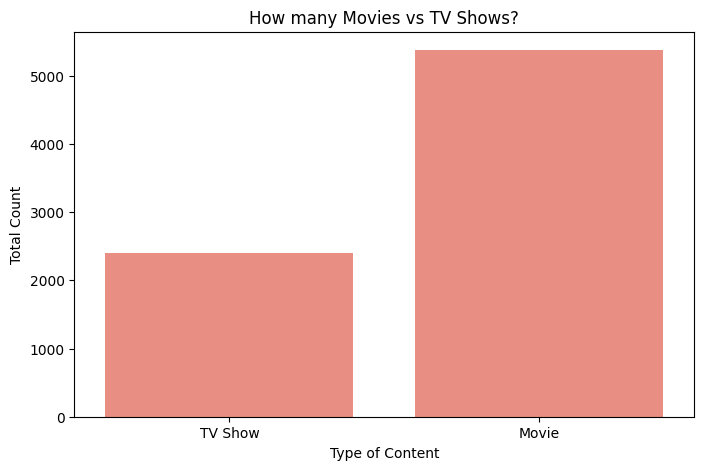

In [28]:
# --- Step 2: Looking at Movies vs TV Shows ---
# I want to see which one Netflix has more of.
# I'll use a simple countplot for this.

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type', color='salmon')
plt.title('How many Movies vs TV Shows?')
plt.xlabel('Type of Content')
plt.ylabel('Total Count')
plt.show()

## 2. Growth of Content Over Time
We will now look at how the number of titles added to Netflix has changed each year.

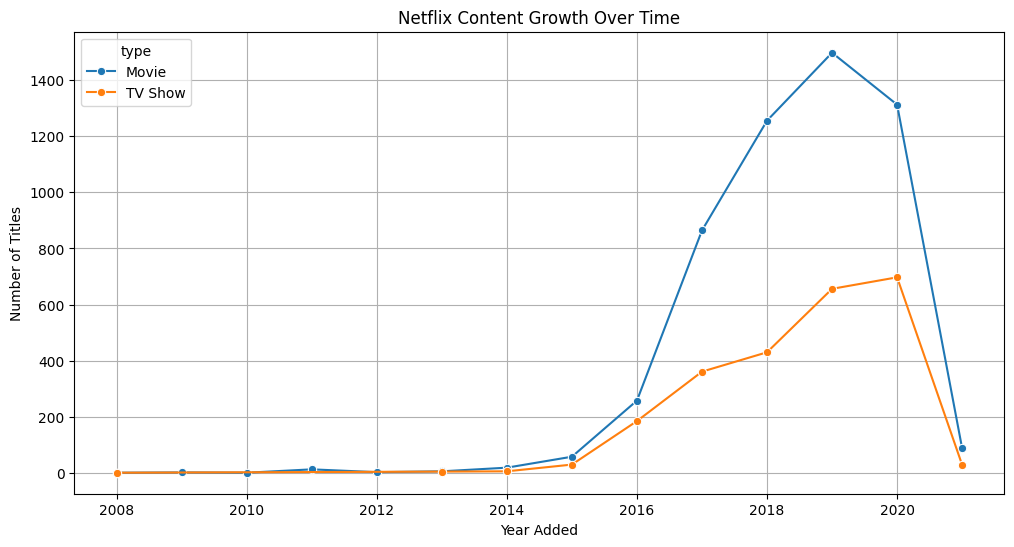

In [29]:
content_growth = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=content_growth, x='year_added', y='count', hue='type', marker='o')
plt.title('Netflix Content Growth Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

## 3. Genre Analysis
Since the `listed_in` column contains multiple genres for a single title, we need to split these values and count the frequency of each genre.

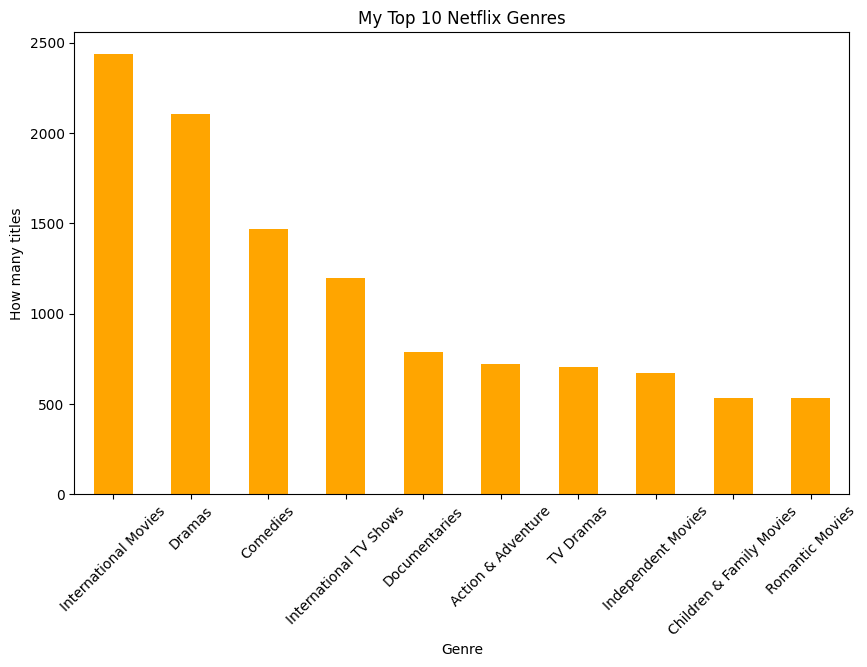

In [30]:
# --- Step 3: Genre Analysis ---
# Checking if the data is ready
if 'df' in globals():
    # The genres are all mixed together with commas, so I need to separate them
    genres_list = []
    for item in df['listed_in']:
        parts = item.split(',')
        for p in parts:
            genres_list.append(p.strip())

    # I'll use a simple pandas series to count which one appears the most
    genre_counts = pd.Series(genres_list).value_counts().head(10)

    # Let's make a simple bar chart
    plt.figure(figsize=(10, 6))
    genre_counts.plot(kind='bar', color='orange')
    plt.title('My Top 10 Netflix Genres')
    plt.xlabel('Genre')
    plt.ylabel('How many titles')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Wait! You need to run the loading and cleaning cells before this one.")

## 4. Geographical Content Distribution
Finally, we look at which countries produce the most content available on the platform.

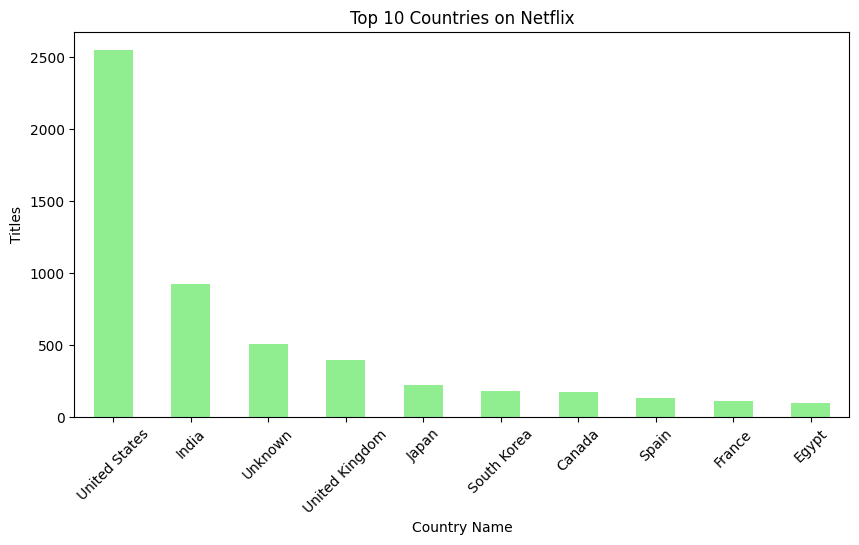

In [31]:
# --- Step 4: Top 10 Countries ---
# Which countries make the most content?
# I'll just use value_counts() to find out.

top_ten = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_ten.plot(kind='bar', color='lightgreen')
plt.title('Top 10 Countries on Netflix')
plt.xlabel('Country Name')
plt.ylabel('Titles')
plt.xticks(rotation=45)
plt.show()

## Final Summary and Observations
After performing this Exploratory Data Analysis, I have identified several key trends on Netflix:

1.  **Content Focus**: There are significantly more Movies than TV Shows, though both have seen massive growth since 2015.
2.  **Top Genres**: International Movies and Dramas dominate the platform, reflecting Netflix's global expansion strategy.
3.  **Regional Leaders**: The United States and India are the primary content hubs for the platform.
4.  **Growth Spikes**: 2018-2019 saw the highest number of new additions, with a slight dip following that period.

Overall, this project shows how Netflix has transitioned from a small service to a massive global library. I've learned how to clean messy data, handle dates in Pandas, and create meaningful charts to tell a story.

In [32]:
# Final count of titles analyzed
print(f'Total titles analyzed: {len(df)}')
print('EDA Project Complete.')

Total titles analyzed: 7777
EDA Project Complete.


### Note on Data
*The dataset is automatically downloaded and loaded in the first code cell of this notebook using `wget` and `pandas`. No manual upload is required.*